In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dados_vendas = {
    'mes': [
      'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',  'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
    ],
    'vendas': [
       2000, 2200, 2300, 2500, 2600, 2700,
       2800, 2900, 3000, 3100, 3200, 3300
    ]
}

In [3]:
dados_vendas

{'mes': ['Janeiro',
  'Fevereiro',
  'Março',
  'Abril',
  'Maio',
  'Junho',
  'Julho',
  'Agosto',
  'Setembro',
  'Outubro',
  'Novembro',
  'Dezembro'],
 'vendas': [2000,
  2200,
  2300,
  2500,
  2600,
  2700,
  2800,
  2900,
  3000,
  3100,
  3200,
  3300]}

In [24]:
df_vendas = pd.DataFrame.from_dict(dados_vendas)

In [25]:
df_vendas

,mes,vendas
0,Janeiro,2000
1,Fevereiro,2200
2,Março,2300
3,Abril,2500
4,Maio,2600
5,Junho,2700
6,Julho,2800
7,Agosto,2900
8,Setembro,3000
9,Outubro,3100


In [26]:
# Mapeamento
mapa_meses = {
    'Janeiro': 1, 'Fevereiro': 2, 'Março': 3, 'Abril': 4,
    'Maio': 5, 'Junho': 6, 'Julho': 7, 'Agosto': 8,
    'Setembro': 9, 'Outubro': 10, 'Novembro': 11, 'Dezembro': 12
}

In [27]:
df_vendas['mes_numerico'] = df_vendas['mes'].map(mapa_meses)


In [28]:
df_vendas

,mes,vendas,mes_numerico
0,Janeiro,2000,1
1,Fevereiro,2200,2
2,Março,2300,3
3,Abril,2500,4
4,Maio,2600,5
5,Junho,2700,6
6,Julho,2800,7
7,Agosto,2900,8
8,Setembro,3000,9
9,Outubro,3100,10


In [29]:
df_vendas_corr = df_vendas.drop(columns=['mes'])

In [30]:
df_vendas_corr

,vendas,mes_numerico
0,2000,1
1,2200,2
2,2300,3
3,2500,4
4,2600,5
5,2700,6
6,2800,7
7,2900,8
8,3000,9
9,3100,10


<Axes: xlabel='mes_numerico', ylabel='vendas'>

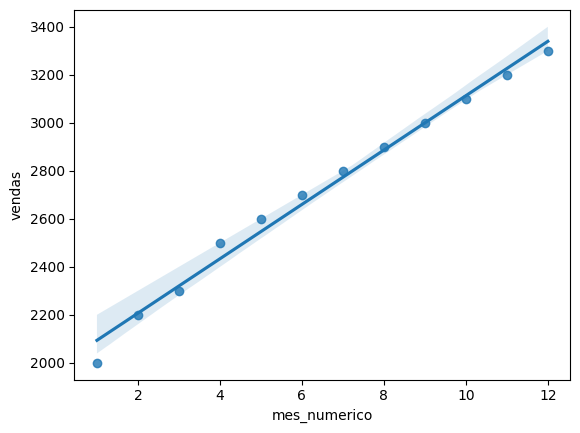

In [31]:
sns.regplot(data=df_vendas_corr, x="mes_numerico", y="vendas")

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [49]:
# Treino: meses 1 a 11
train = df_vendas_corr[df_vendas_corr['mes_numerico'] <= 11]

In [50]:
# Teste: mes 12
test = df_vendas_corr[df_vendas_corr['mes_numerico'] == 12]

In [51]:
X_train = train[['mes_numerico']]
y_train = train['vendas']

In [53]:
X_test = test[['mes_numerico']]
y_test = test['vendas']

In [54]:
# Treinar o algoritmo de Regressão Linear - Modelo 1
model_1 = LinearRegression().fit(X_train, y_train)

In [55]:
# Gerar predições do conjunto de testes com base no Modelo 1
y_pred = model_1.predict(X_test)

In [ ]:
# Previsao da venda de Dezembro
y_pred

array([3356.36363636])

array([[<Axes: title={'center': 'vendas'}>,
        <Axes: title={'center': 'mes_numerico'}>]], dtype=object)

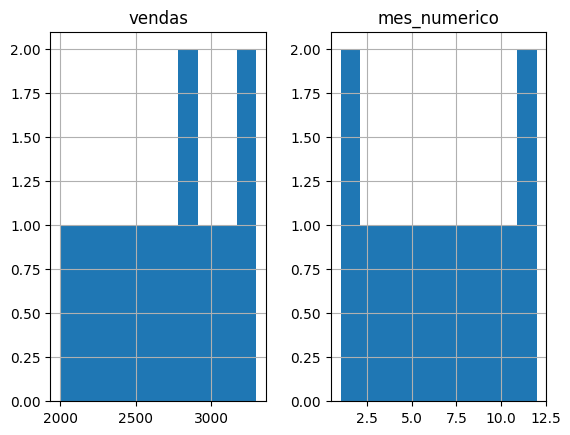

In [62]:
df_vendas_corr.hist()

array([[<Axes: xlabel='vendas', ylabel='vendas'>,
        <Axes: xlabel='mes_numerico', ylabel='vendas'>],
       [<Axes: xlabel='vendas', ylabel='mes_numerico'>,
        <Axes: xlabel='mes_numerico', ylabel='mes_numerico'>]],
      dtype=object)

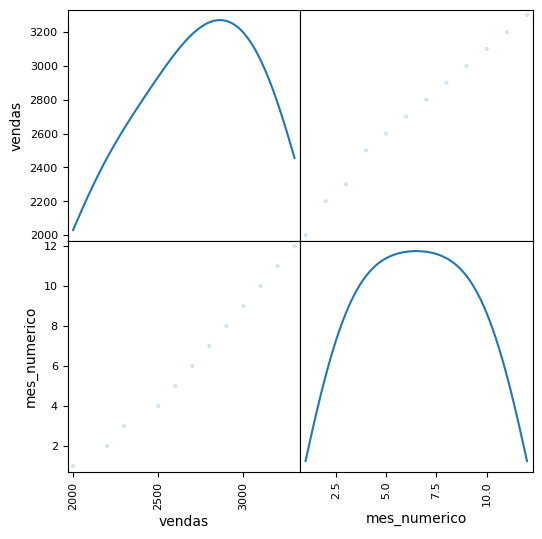

In [63]:
pd.plotting.scatter_matrix(df_vendas_corr, alpha=0.2, figsize=(6, 6), diagonal='kde')